In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df=pd.read_csv("../data/cleaned_student_data.csv")

## Phase 1: Target Variable Analysis (G3)

G3 represents the final academic performance of the student and is the primary target variable for this analysis.  
Understanding its distribution helps assess overall performance trends and guides model selection.

### What to Observe
- Is the distribution skewed or approximately normal?
- Are most students average performers?
- Are there any extreme values (very low or very high scores)?


**using histogram for G3 distribution overview👇🏻**


<Axes: >

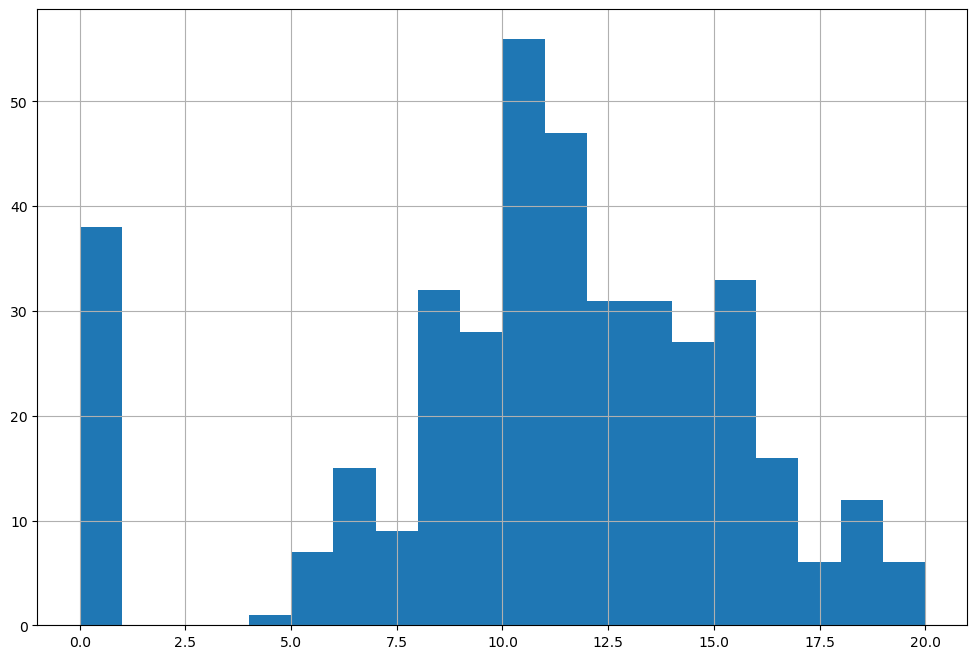

In [9]:
df['G3'].hist(bins=20,figsize=(12,8))

### Observations from G3 Distribution

- The final grade (G3) ranges from 0 to 20.
- Most students score between 8 and 15, indicating average academic performance.
- A noticeable spike at 0 suggests students who failed or did not complete the final exam.
- The distribution is slightly left-skewed and not perfectly normal.
- These patterns indicate that regression-based models are suitable, while outliers should be interpreted as meaningful academic outcomes rather than removed.


## Phase 2: Univariate Analysis (Numerical Features)

In this phase, individual numerical features are analyzed independently to understand their distribution, spread, and presence of outliers.

### Features Analyzed
- studytime
- absences
- failures

### What to Observe
- Range and distribution of values
- Presence of outliers
- Whether the feature is evenly distributed or skewed


Text(0.5, 1.0, 'Study Time Distribution')

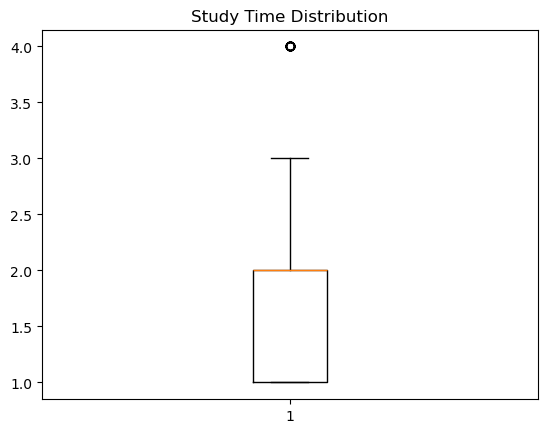

In [32]:
plt.boxplot(df['studytime'])
plt.title("Study Time Distribution")


### Observations from Study Time Distribution

- The median study time category is 2, indicating most students study between 2–5 hours per week.
- 50% of students fall between study time categories 1 and 2, showing a concentration toward lower study durations.
- Very few students study more than 10 hours per week, which appears as an outlier.
- These high study time values represent valid academic behavior and are retained for further analysis.
- Overall, the distribution is right-skewed with limited variability.


**Component	Meaning in our Plot**
- Bottom of box:-Many students study <2 hrs
- Median line	Most students study 2–5 hrs
- Top of box	Upper limit of typical study
- Upper whisker	Few students study 5–10 hrs
- Dot at 4	Very few study >10 hrs

Text(0.5, 1.0, 'Absences Distribution')

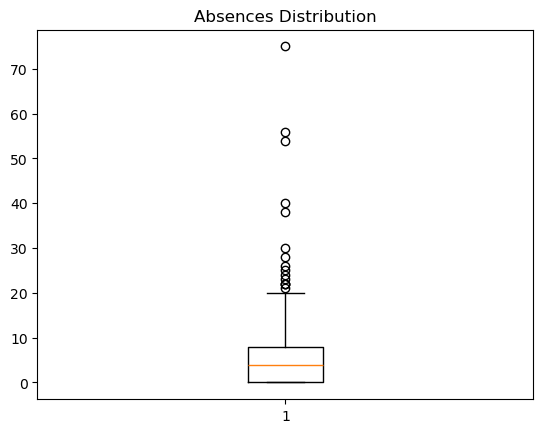

In [33]:
plt.boxplot(df['absences'])
plt.title("Absences Distribution")


{'whiskers': [<matplotlib.lines.Line2D at 0x164b7ab70>,
 'caps': [<matplotlib.lines.Line2D at 0x164b7b0b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x164b7a840>],
 'medians': [<matplotlib.lines.Line2D at 0x164b7b5f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x164b7b890>],
 'means': []}

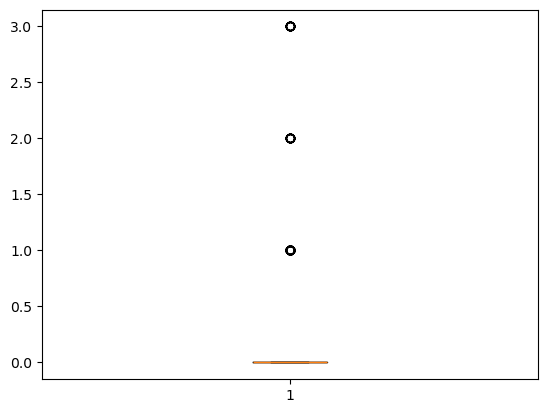

In [12]:
plt.boxplot(df['failures'])

{'whiskers': [<matplotlib.lines.Line2D at 0x167118e90>,
 'caps': [<matplotlib.lines.Line2D at 0x1671194f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x167118c50>],
 'medians': [<matplotlib.lines.Line2D at 0x167119a00>],
 'fliers': [<matplotlib.lines.Line2D at 0x167119ca0>],
 'means': []}

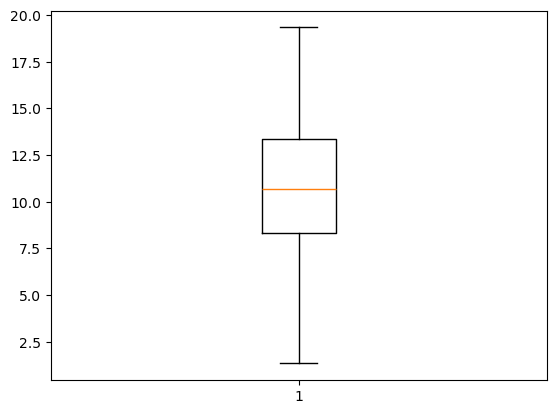

In [14]:
plt.boxplot(df['avg_grade'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1670de7b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1670df920>,
 'boxes': [<matplotlib.lines.Line2D at 0x1670deab0>],
 'medians': [<matplotlib.lines.Line2D at 0x1670dfef0>],
 'fliers': [<matplotlib.lines.Line2D at 0x167324200>],
 'means': []}

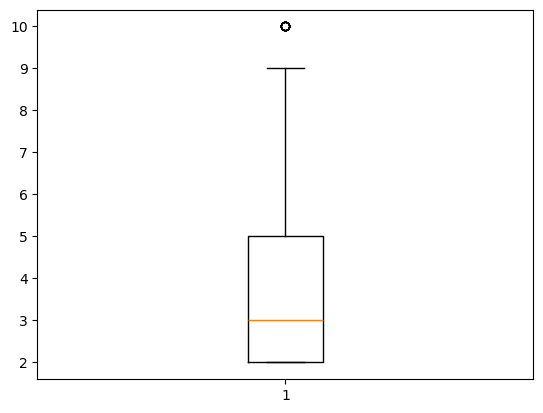

In [15]:
plt.boxplot(df['total_alcohol'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1673418e0>,
 'caps': [<matplotlib.lines.Line2D at 0x167341eb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x167341610>],
 'medians': [<matplotlib.lines.Line2D at 0x1673424e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x167342690>],
 'means': []}

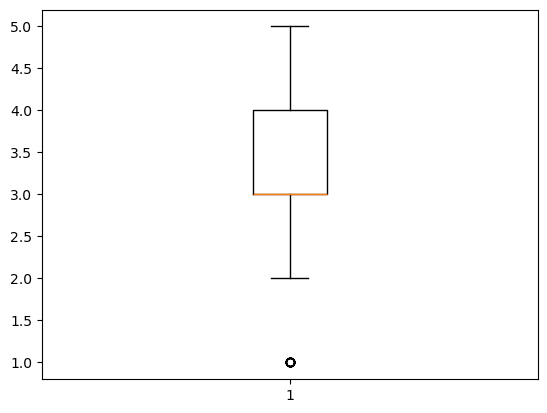

In [16]:
plt.boxplot(df['freetime'])

## Phase 3: Bivariate Analysis (Numerical Features vs G3)

This phase explores how numerical features influence the final grade (G3).


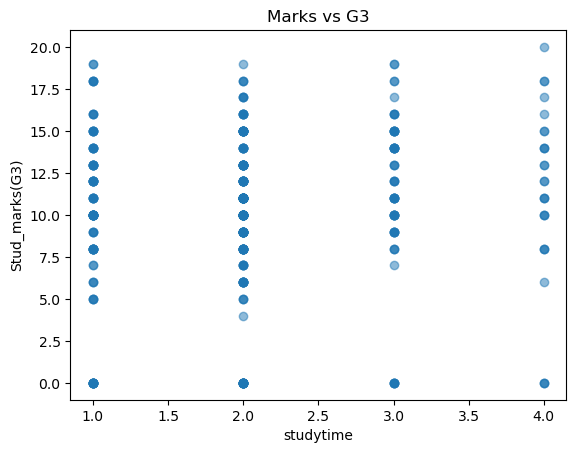

In [40]:
plt.scatter(df['studytime'], df['G3'],alpha=0.5)
plt.xlabel("studytime")
plt.ylabel("Stud_marks(G3)")
plt.title("Marks vs G3")
plt.show()


**From the Studytime vs G3 plot:**
- Each dot represents a student.
- Studytime is a categorical variable (1–4), not exact hours.
- Students with higher studytime categories (3 and 4) show more concentration in the mid-to-high score range (10–20).
- Lower studytime categories (1 and 2) show wider score variation, including lower grades.
- This suggests that increased studytime is positively associated with better academic performance, though it is not the only determining factor.


Text(0.5, 1.0, 'Absences vs G3')

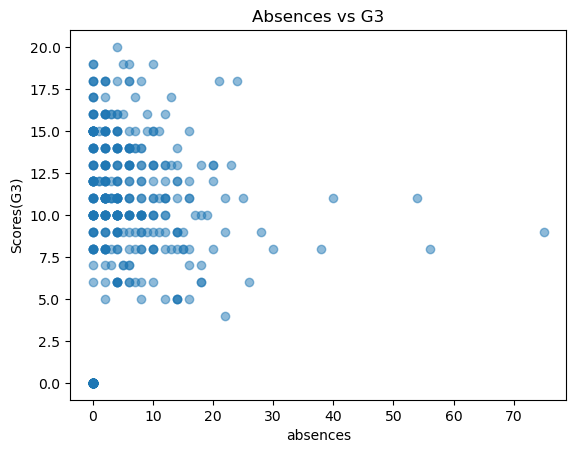

In [41]:
plt.scatter(df['absences'],df['G3'],alpha=0.5)
plt.xlabel("absences")
plt.ylabel("Scores(G3)")
plt.title("Absences vs G3")

**From the Absences vs G3 plot:**
- Most students have absences in the range of 0–25 days.
- Students with fewer absences generally tend to achieve higher final grades.
- An outlier is observed where a student with zero absences scored zero marks, indicating that attendance alone does not guarantee academic success.
- Another outlier shows a student with high absences still scoring a moderate grade, suggesting that other factors influence performance.

**Overall Insight:**
- Absences show a weak to moderate negative relationship with final grades.
- Attendance contributes to performance but is not the sole determining factor.
- Other features such as studytime and previous academic scores (G1, G2) likely play a stronger role.


## Academic History vs Final Performance

Previous academic performance is expected to strongly influence final grades.


array([[<Axes: xlabel='G1', ylabel='G1'>,
        <Axes: xlabel='G2', ylabel='G1'>,
        <Axes: xlabel='G3', ylabel='G1'>],
       [<Axes: xlabel='G1', ylabel='G2'>,
        <Axes: xlabel='G2', ylabel='G2'>,
        <Axes: xlabel='G3', ylabel='G2'>],
       [<Axes: xlabel='G1', ylabel='G3'>,
        <Axes: xlabel='G2', ylabel='G3'>,
        <Axes: xlabel='G3', ylabel='G3'>]], dtype=object)

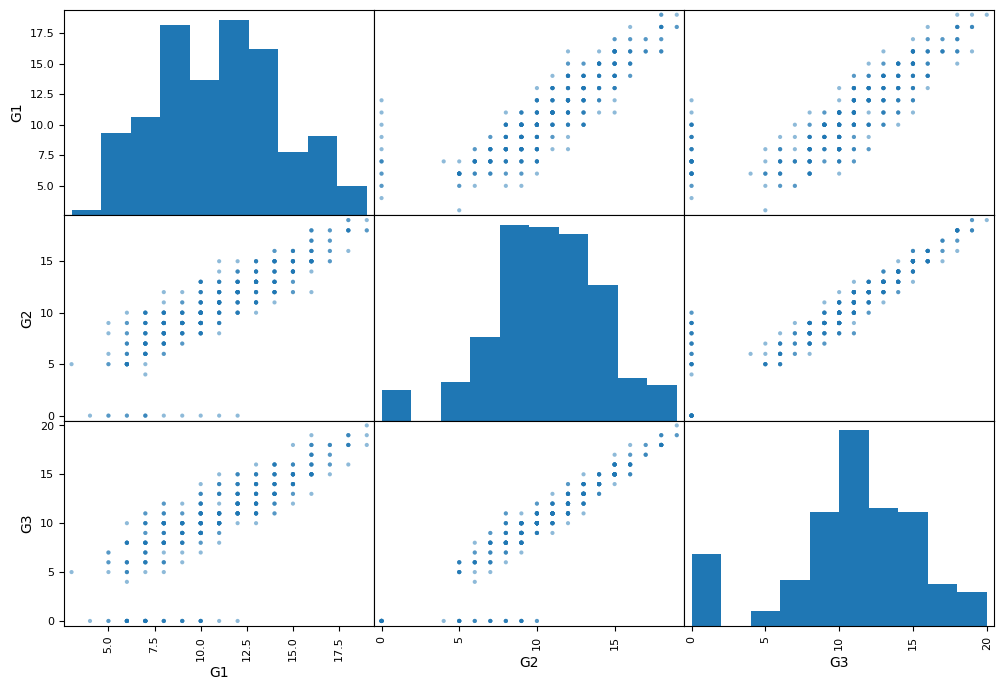

In [42]:
from pandas.plotting import scatter_matrix
attributes=["G1","G2","G3"]
scatter_matrix(df[attributes],figsize=(12,8), alpha=0.5)

### Relationship Between Internal and Final Grades (G1, G2, G3)

From the scatter matrix analysis:

- G1 and G2 show a strong positive linear relationship, indicating consistency in student performance across internal assessments.
- G2 and G3 exhibit an even stronger correlation, suggesting that second-term performance is the most influential factor in determining final grades.
- G1 also shows a strong positive relationship with G3, though slightly weaker compared to G2.
- Students with very low or zero internal grades (G1 or G2) almost always score poorly in the final exam.
- Overall, academic performance appears cumulative, where past exam results strongly influence future outcomes.

Conclusion:
- G2 is the strongest predictor of G3.
- G1 is also an important predictor but slightly less influential than G2.
- These findings justify the inclusion of G1 and G2 as key features in predictive modeling.


## Phase 4: Categorical Features vs Final Grade (G3)

This phase analyzes how categorical features influence student performance.


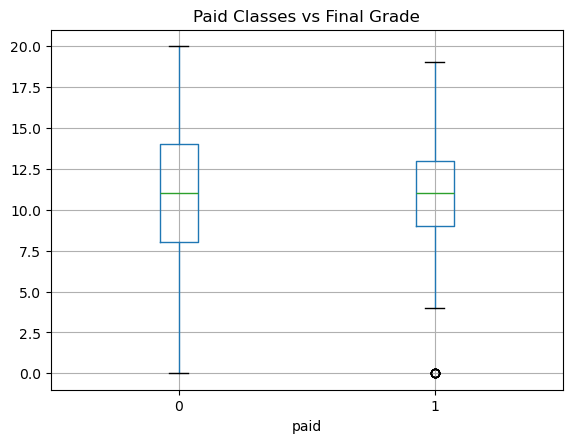

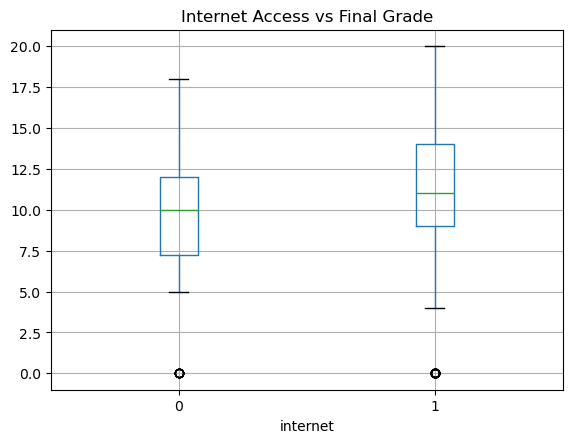

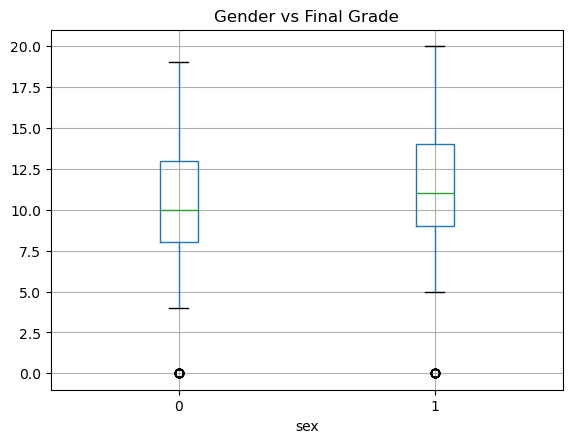

In [43]:
df.boxplot(column='G3', by='paid')
plt.title("Paid Classes vs Final Grade")
plt.suptitle("")
plt.show()

df.boxplot(column='G3', by='internet')
plt.title("Internet Access vs Final Grade")
plt.suptitle("")
plt.show()

df.boxplot(column='G3', by='sex')
plt.title("Gender vs Final Grade")
plt.suptitle("")
plt.show()


Gender does not show a significant difference in academic performance.
- Internet access provides a marginal advantage but is not a decisive factor.

## Key Insights from Exploratory Data Analysis

- G1 and G2 have a strong positive correlation with G3.
- Study time shows a mild positive relationship with final grades.
- Higher absences tend to be associated with lower performance.
- Categorical features such as paid classes and internet access show limited but noticeable influence.
- Academic history is the most dominant factor affecting final performance.


## Feature Selection Rationale

Based on exploratory data analysis and visual inspection of relationships with the target variable (G3), the following features were identified as most relevant for machine learning modeling.

### Strong Predictors
These features show a clear and consistent relationship with the final grade (G3) and represent direct academic performance indicators:

- G1 (First period grade)
- G2 (Second period grade)
- failures (Number of past class failures)
- absences (Total number of school absences)
- studytime (Weekly study time)

### Moderate Predictors
These features influence academic performance indirectly by providing behavioral, environmental, or support-related context:

- paid (Extra paid classes)
- internet (Internet access at home)
- famsup (Family educational support)
- schoolsup (School educational support)
- activities (Participation in extracurricular activities)
- health (Student’s health condition)

Other features showed weak or indirect influence and were excluded from the initial model to reduce noise and improve interpretability.

This finalized feature set will be used for encoding, scaling, and machine learning model training in subsequent notebooks.



### Correlation Heatmap (Feature Selection Validation)

To validate the shortlisted features, a correlation heatmap was generated using
only numerical features that showed meaningful relationships during exploratory
analysis.

Categorical features were excluded to avoid misleading correlations introduced
by binary encoding.

The heatmap helps in:
- Identifying features strongly correlated with the target variable (G3)
- Detecting multicollinearity among predictors (e.g., G1 and G2)
- Justifying the final feature set for machine learning models


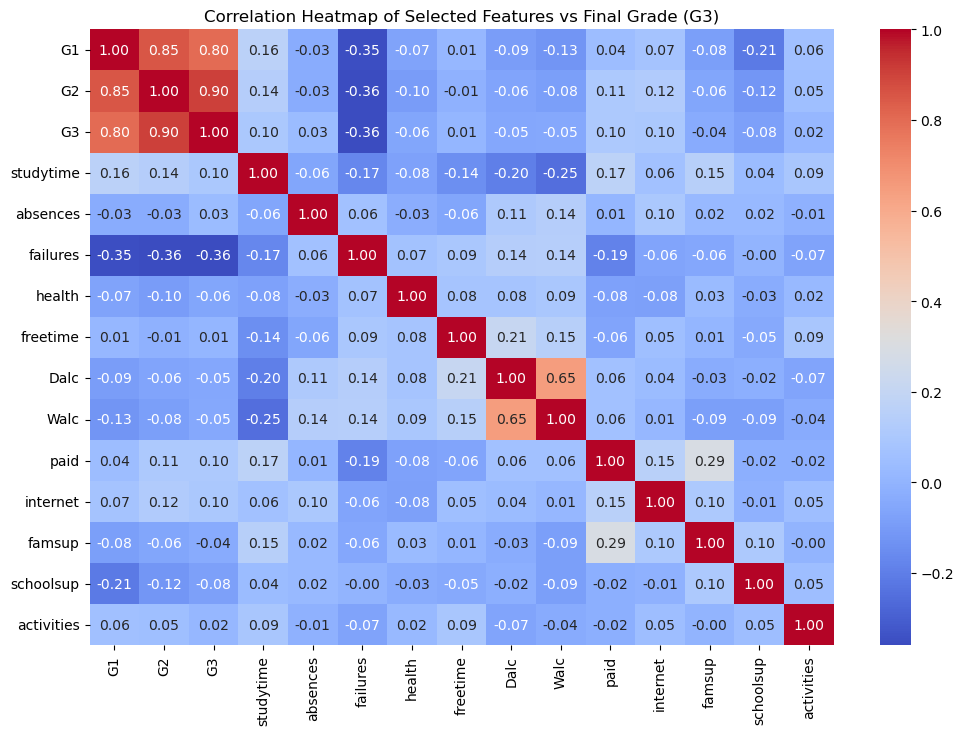

In [50]:
import seaborn as sns
selected_features = [
    'G1', 'G2', 'G3',
    'studytime',
    'absences',
    'failures',
    'health',
    'freetime',
    'Dalc',
    'Walc','paid','internet','famsup','schoolsup','activities'
]

plt.figure(figsize=(12,8))
sns.heatmap(df[selected_features].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap of Selected Features vs Final Grade (G3)')
plt.show()


## Correlation Analysis Insights

The correlation heatmap highlights the strength and direction of relationships between selected features and the target variable (G3).

### Key Observations
- G2 shows the strongest positive correlation with G3 (0.90), making it the most influential predictor.
- G1 also demonstrates a strong positive relationship (0.80), confirming the importance of early academic performance.
- failures has a moderate negative correlation (–0.36), indicating that repeated failures significantly reduce final grades.

### Moderate and Weak Influences
- studytime, paid classes, and internet access show weak positive correlations with G3.
- absences exhibits a weak linear correlation but remains important due to non-linear and outlier effects observed during scatter analysis.
- health, activities, freetime, and schoolsup show minimal direct correlation with final performance.

### Additional Insight
- Daily (Dalc) and weekend (Walc) alcohol consumption are strongly correlated with each other but show weak direct influence on academic performance.

Overall, this analysis validates the selected feature set and supports proceeding with machine learning modeling using the identified strong and moderate predictors.


## Notebook Status

Notebook 04 completed successfully.

- Exploratory Data Analysis (EDA) finalized  
- Feature relationships with target variable (G3) analyzed  
- Final feature set selected and locked  

Ready to proceed with feature encoding and machine learning modeling.
